# 06 - Evaluation: Models Evaluation Comparison


In this notebook, we perform a comparative analysis of all trained models using:
- Metric distribution analysis and comparison (plots and summary statistics)
- Statistical significance testing (Corrected Resampled t-test)


## Import libraries and set the paths

In [1]:
from __future__ import annotations

import IPython.display as ipd
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

from fraud_dynamic_ensemble.config import MODELS_DIR, FIGURES_DIR
from fraud_dynamic_ensemble.evaluation.visual_evaluation import plot_model_distribution, plot_model_barplot
from fraud_dynamic_ensemble.evaluation.statistical_test_evaluation import compute_pairwise_corrected_resampled_ttest

2026-02-04 19:17:56.689 | INFO     | fraud_dynamic_ensemble.config:<module>:14 - PROJ_ROOT path is: /home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection


In [2]:
EXPERIMENT_NAME = "CostSensitiveLearning_ClusterCentroids___RandomizedSearchCV__niter_30__cv_5"

In [3]:
models_results_path: Path = MODELS_DIR / EXPERIMENT_NAME
print(f"Loading results at path:\n\t{models_results_path}")

Loading results at path:
	/home/leonardosaccotelli/Desktop/UNIVERSITA/MACHINE-LEARNING/Dynamic-Ensemble-Learning-for-Credit-Card-Fraud-Detection/models/CostSensitiveLearning_ClusterCentroids___RandomizedSearchCV__niter_30__cv_5


In [4]:
FIGURES_MODELS_COMPARISON_DIR = FIGURES_DIR / "EV_models_comparison_evaluation"
FIGURES_MODELS_COMPARISON_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_MODELS_COMPARISON_EXPERIMENT_DIR = FIGURES_MODELS_COMPARISON_DIR / EXPERIMENT_NAME
FIGURES_MODELS_COMPARISON_EXPERIMENT_DIR.mkdir(parents=True, exist_ok=True)

FIGURES_MULTIPLE_MODELS_EVALUATION_DIR = FIGURES_MODELS_COMPARISON_EXPERIMENT_DIR / "multiple_models_evaluation"
FIGURES_MULTIPLE_MODELS_EVALUATION_DIR.mkdir(parents=True, exist_ok=True)

In [5]:
pd.set_option("display.max_columns", None)
plt.rcParams.update({"font.size": 16})
sns.set_style("whitegrid")
sns.set_palette("tab10")

## Data Loading and Basic Overview

In [6]:
files = list(models_results_path.glob("*/generalization_metrics_summary.csv"))
generalization_df = pd.DataFrame()

print(f"Found {len(files)} files. Loading...")

if files:
    # Read and Concatenate
    # We use a generator expression inside concat for memory efficiency
    generalization_df = pd.concat((pd.read_csv(f) for f in files), ignore_index=True)

    print("Success! Combined dataframe shape:", generalization_df.shape)
else:
    print(f"No files found in {models_results_path.absolute()}")

Found 23 files. Loading...
Success! Combined dataframe shape: (2300, 25)


In [7]:
generalization_df

,experiment_name,iteration,fold,model,split,tp,tn,fp,fn,accuracy,precision,recall,f1,specificity,fpr,balanced_accuracy,geometric_mean,mcc,kappa,roc_auc,average_precision,score_time,fold_size,selected_features_indices,selected_features_names
0,CostSensitiveLearning_ClusterCentroids___Rando...,1,1,KNOP,generalization,44,2459,1,3,0.998404,0.977778,0.936170,0.956522,0.999593,0.000407,0.967882,0.967362,0.955944,0.955709,0.966182,0.940282,8.330016,2507,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
1,CostSensitiveLearning_ClusterCentroids___Rando...,1,2,KNOP,generalization,38,2441,19,9,0.988831,0.666667,0.808511,0.730769,0.992276,0.007724,0.900394,0.895693,0.728640,0.725120,0.901946,0.781394,12.912033,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2,CostSensitiveLearning_ClusterCentroids___Rando...,1,3,KNOP,generalization,39,2439,21,8,0.988432,0.650000,0.829787,0.728972,0.991463,0.008537,0.910625,0.907030,0.728785,0.723151,0.946277,0.851354,8.510864,2507,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
3,CostSensitiveLearning_ClusterCentroids___Rando...,1,4,KNOP,generalization,38,2431,29,9,0.984842,0.567164,0.808511,0.666667,0.988211,0.011789,0.898361,0.893856,0.670025,0.659156,0.917575,0.776834,12.846378,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
4,CostSensitiveLearning_ClusterCentroids___Rando...,1,5,KNOP,generalization,42,2458,1,6,0.997208,0.976744,0.875000,0.923077,0.999593,0.000407,0.937297,0.935224,0.923106,0.921659,0.927604,0.888953,7.948729,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2295,CostSensitiveLearning_ClusterCentroids___Rando...,10,6,APriori,generalization,41,2390,69,7,0.969685,0.372727,0.854167,0.518987,0.971940,0.028060,0.913053,0.911152,0.552720,0.505813,0.940944,0.854872,5.201206,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2296,CostSensitiveLearning_ClusterCentroids___Rando...,10,7,APriori,generalization,38,2399,60,10,0.972078,0.387755,0.791667,0.520548,0.975600,0.024400,0.883633,0.878834,0.542519,0.507899,0.911630,0.740705,3.318754,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2297,CostSensitiveLearning_ClusterCentroids___Rando...,10,8,APriori,generalization,40,2394,65,7,0.971269,0.380952,0.851064,0.526316,0.973566,0.026434,0.912315,0.910257,0.558337,0.513715,0.960285,0.792263,10.881140,2506,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2298,CostSensitiveLearning_ClusterCentroids___Rando...,10,9,APriori,generalization,39,2412,47,8,0.978053,0.453488,0.829787,0.586466,0.980887,0.019113,0.905337,0.902179,0.604112,0.576187,0.903113,0.810056,9.913502,2506,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."


## Fix the metrics and model to evaluate and compare

In [8]:
metrics_to_analyze = [
    "balanced_accuracy",
    "average_precision",
    "f1"
]
print(f"Selected metrics:\n\t{metrics_to_analyze}")

Selected metrics:
	['balanced_accuracy', 'average_precision', 'f1']


In [9]:
#models_to_analyze = ["APriori", "APosteriori", "KNORAE", "MLPClassifier", ]
models_to_analyze = generalization_df["model"].unique()
print(f"Selected models:\n\t{models_to_analyze}")

generalization_df = generalization_df[generalization_df["model"].isin(models_to_analyze)]
generalization_df

Selected models:
	['KNOP' 'KNORAE' 'APosteriori' 'KNeighborsClassifier' 'Exponential'
 'LogitBoostClassifier' 'BalancedRandomForestClassifier'
 'DecisionTreeClassifier' 'StackingClassifier' 'DESKL' 'XGBClassifier'
 'Logarithmic' 'RUSBoostClassifier' 'MLA' 'RandomForestClassifier'
 'KNORAU' 'MLPClassifier' 'ExtraTreesClassifier' 'VotingClassifier' 'RRC'
 'METADES' 'DESP' 'APriori']


,experiment_name,iteration,fold,model,split,tp,tn,fp,fn,accuracy,precision,recall,f1,specificity,fpr,balanced_accuracy,geometric_mean,mcc,kappa,roc_auc,average_precision,score_time,fold_size,selected_features_indices,selected_features_names
0,CostSensitiveLearning_ClusterCentroids___Rando...,1,1,KNOP,generalization,44,2459,1,3,0.998404,0.977778,0.936170,0.956522,0.999593,0.000407,0.967882,0.967362,0.955944,0.955709,0.966182,0.940282,8.330016,2507,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
1,CostSensitiveLearning_ClusterCentroids___Rando...,1,2,KNOP,generalization,38,2441,19,9,0.988831,0.666667,0.808511,0.730769,0.992276,0.007724,0.900394,0.895693,0.728640,0.725120,0.901946,0.781394,12.912033,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2,CostSensitiveLearning_ClusterCentroids___Rando...,1,3,KNOP,generalization,39,2439,21,8,0.988432,0.650000,0.829787,0.728972,0.991463,0.008537,0.910625,0.907030,0.728785,0.723151,0.946277,0.851354,8.510864,2507,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."
3,CostSensitiveLearning_ClusterCentroids___Rando...,1,4,KNOP,generalization,38,2431,29,9,0.984842,0.567164,0.808511,0.666667,0.988211,0.011789,0.898361,0.893856,0.670025,0.659156,0.917575,0.776834,12.846378,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
4,CostSensitiveLearning_ClusterCentroids___Rando...,1,5,KNOP,generalization,42,2458,1,6,0.997208,0.976744,0.875000,0.923077,0.999593,0.000407,0.937297,0.935224,0.923106,0.921659,0.927604,0.888953,7.948729,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2295,CostSensitiveLearning_ClusterCentroids___Rando...,10,6,APriori,generalization,41,2390,69,7,0.969685,0.372727,0.854167,0.518987,0.971940,0.028060,0.913053,0.911152,0.552720,0.505813,0.940944,0.854872,5.201206,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2296,CostSensitiveLearning_ClusterCentroids___Rando...,10,7,APriori,generalization,38,2399,60,10,0.972078,0.387755,0.791667,0.520548,0.975600,0.024400,0.883633,0.878834,0.542519,0.507899,0.911630,0.740705,3.318754,2507,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2297,CostSensitiveLearning_ClusterCentroids___Rando...,10,8,APriori,generalization,40,2394,65,7,0.971269,0.380952,0.851064,0.526316,0.973566,0.026434,0.912315,0.910257,0.558337,0.513715,0.960285,0.792263,10.881140,2506,"[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 16...","['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8..."
2298,CostSensitiveLearning_ClusterCentroids___Rando...,10,9,APriori,generalization,39,2412,47,8,0.978053,0.453488,0.829787,0.586466,0.980887,0.019113,0.905337,0.902179,0.604112,0.576187,0.903113,0.810056,9.913502,2506,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13,...","['Amount_log1p', 'V1', 'V2', 'V3', 'V4', 'V5',..."


## Model Comparison (Distribution Analysis)

### Objective
To compare the performance distribution of all models for a specific metric on a targeted data split (e.g., Generalization or Resubstitution).

### Methodology
We generate a **distribution plot** and a **statistical report** for the selected metric and split:
* **Scope:** Parametrizable (Default: **Generalization**).
* **Visualization:**
    * **Boxplot:** Displays the median, Interquartile Range (IQR), and spread.
    * **Strip Plot:** Overlays raw data points (100 folds) to visualize density.
* **Statistics:** A summary table (Mean, Std, Min, Max) is displayed and saved to quantify the visual results.
* **Sorting:** Models are sorted **Alphabetically** to ensure consistent ordering across different plots.
* **Scale:** Fixed to $0.0 - 1.0$ (or customized based on metric range).

### Interpretation Guide
* **Box Height:** Higher is better for standard metrics (e.g., F1, MCC). Lower is better for error metrics.
* **Box Size (IQR):** A short box implies high stability (low variance). A tall box implies the model behavior changes drastically depending on the data fold.
* **Split Comparison:** By generating this plot for both 'resubstitution' and 'generalization', one can visually confirm overfitting (if the Resubstitution box is high/tight while the Generalization box is low/wide).


DISTRIBUTION ANALYSIS: BALANCED_ACCURACY (GENERALIZATION)


,balanced_accuracy_count,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_min,balanced_accuracy_25%,balanced_accuracy_50%,balanced_accuracy_75%,balanced_accuracy_max
model,,,,,,,,
APosteriori,100.0,0.906826,0.032154,0.818539,0.892143,0.911946,0.928545,0.974453
APriori,100.0,0.898794,0.028927,0.802076,0.881452,0.903308,0.920467,0.955275
BalancedRandomForestClassifier,100.0,0.818028,0.082352,0.571777,0.763674,0.826290,0.879927,0.953589
DESKL,100.0,0.912242,0.028512,0.839206,0.895376,0.914690,0.935408,0.977097
DESP,100.0,0.915432,0.027721,0.834325,0.901960,0.916018,0.935490,0.973437
DecisionTreeClassifier,100.0,0.886286,0.041179,0.770223,0.861397,0.892804,0.914233,0.966256
Exponential,100.0,0.915643,0.027900,0.838596,0.902374,0.913471,0.934442,0.975267
ExtraTreesClassifier,100.0,0.907827,0.029528,0.829177,0.893210,0.906148,0.925564,0.977707
KNOP,100.0,0.914993,0.025772,0.844760,0.900003,0.916150,0.933914,0.968760


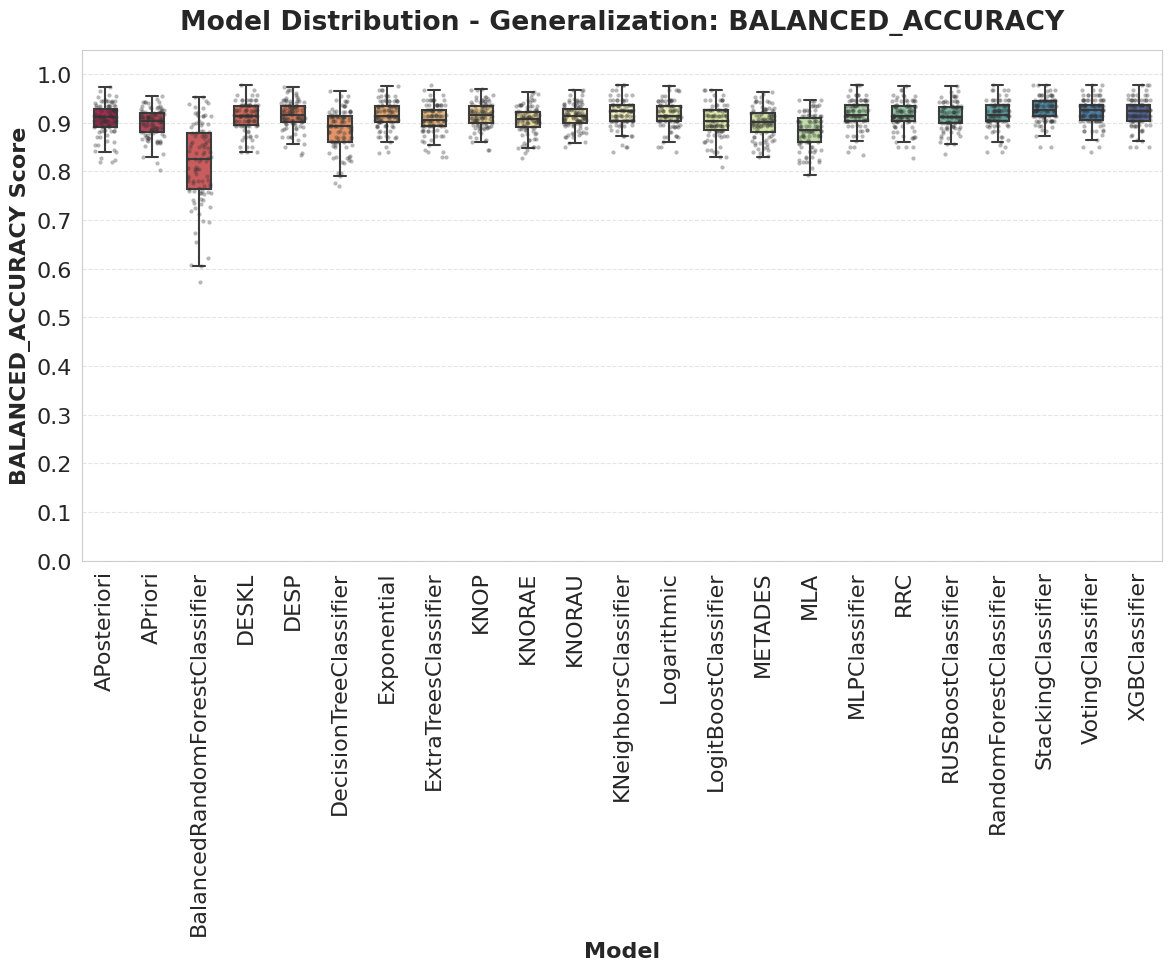


DISTRIBUTION ANALYSIS: AVERAGE_PRECISION (GENERALIZATION)


,average_precision_count,average_precision_mean,average_precision_std,average_precision_min,average_precision_25%,average_precision_50%,average_precision_75%,average_precision_max
model,,,,,,,,
APosteriori,100.0,0.808726,0.064405,0.542138,0.781877,0.824026,0.850823,0.910808
APriori,100.0,0.771879,0.071301,0.562157,0.729687,0.775135,0.829399,0.901411
BalancedRandomForestClassifier,100.0,0.863319,0.044723,0.720745,0.837450,0.867377,0.894200,0.956524
DESKL,100.0,0.861856,0.046686,0.724053,0.833976,0.865600,0.894639,0.939247
DESP,100.0,0.831070,0.064567,0.584694,0.797356,0.840758,0.876203,0.952724
DecisionTreeClassifier,100.0,0.669565,0.125700,0.218440,0.602576,0.687793,0.758488,0.861495
Exponential,100.0,0.818637,0.073755,0.652062,0.771763,0.830234,0.871409,0.940646
ExtraTreesClassifier,100.0,0.869220,0.042285,0.744068,0.848674,0.872283,0.897254,0.942342
KNOP,100.0,0.843365,0.051028,0.692645,0.813927,0.845605,0.877527,0.942826


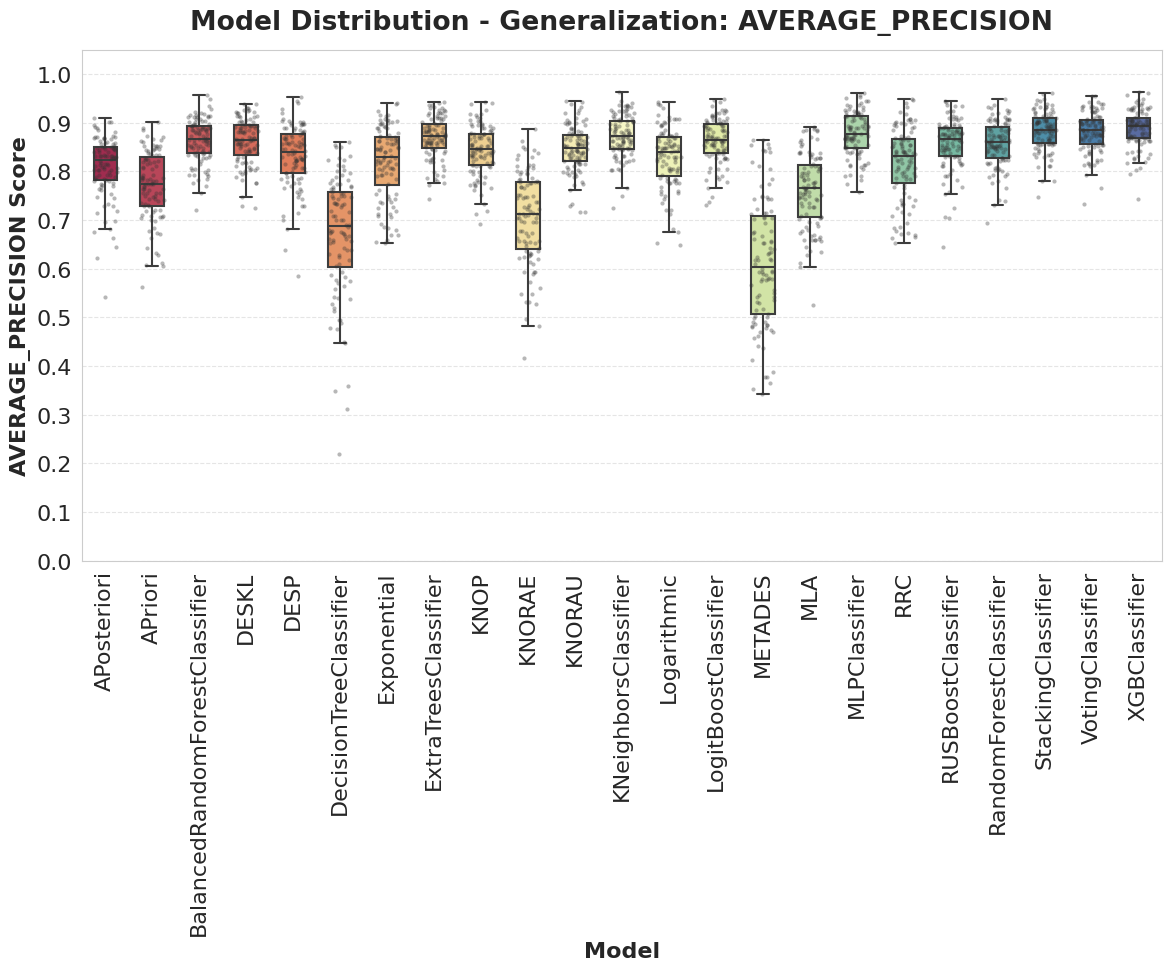


DISTRIBUTION ANALYSIS: F1 (GENERALIZATION)


,f1_count,f1_mean,f1_std,f1_min,f1_25%,f1_50%,f1_75%,f1_max
model,,,,,,,,
APosteriori,100.0,0.816505,0.060040,0.616541,0.780000,0.825415,0.857143,0.924731
APriori,100.0,0.500971,0.062799,0.330508,0.465078,0.500000,0.542506,0.661417
BalancedRandomForestClassifier,100.0,0.127776,0.068433,0.043597,0.076995,0.102144,0.169497,0.342007
DESKL,100.0,0.877038,0.036666,0.752941,0.856340,0.883721,0.900275,0.945055
DESP,100.0,0.744776,0.110365,0.523490,0.670765,0.734754,0.823897,0.956522
DecisionTreeClassifier,100.0,0.767988,0.088316,0.400000,0.728693,0.780805,0.826296,0.903226
Exponential,100.0,0.819069,0.047706,0.672269,0.787879,0.818602,0.852206,0.956522
ExtraTreesClassifier,100.0,0.882115,0.036138,0.765432,0.860465,0.885042,0.907505,0.956522
KNOP,100.0,0.705957,0.155166,0.404145,0.594595,0.720721,0.830261,0.956522


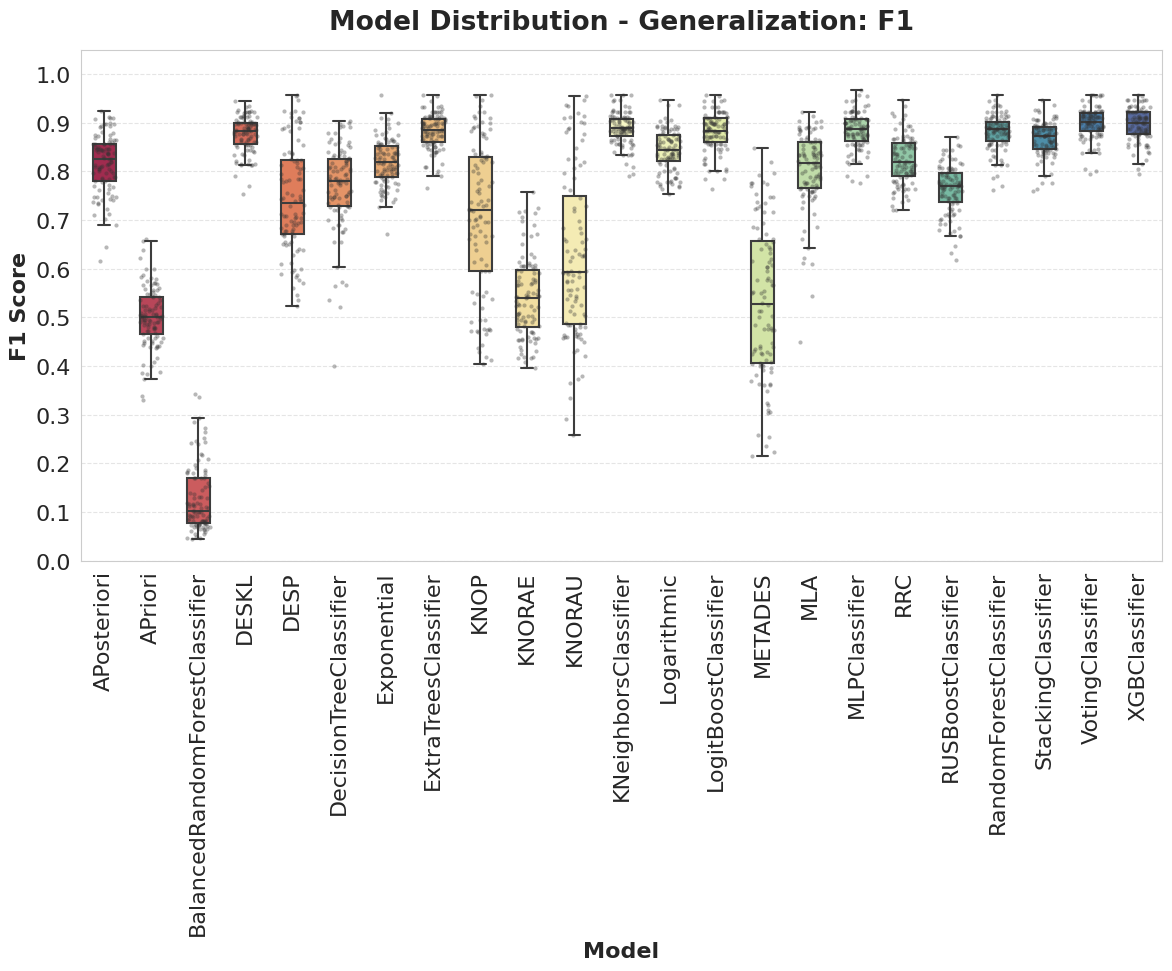


FINAL DISTRIBUTION SUMMARY


,balanced_accuracy_count,balanced_accuracy_mean,balanced_accuracy_std,balanced_accuracy_min,balanced_accuracy_25%,balanced_accuracy_50%,balanced_accuracy_75%,balanced_accuracy_max,average_precision_count,average_precision_mean,average_precision_std,average_precision_min,average_precision_25%,average_precision_50%,average_precision_75%,average_precision_max,f1_count,f1_mean,f1_std,f1_min,f1_25%,f1_50%,f1_75%,f1_max
model,,,,,,,,,,,,,,,,,,,,,,,,
APosteriori,100.0,0.906826,0.032154,0.818539,0.892143,0.911946,0.928545,0.974453,100.0,0.808726,0.064405,0.542138,0.781877,0.824026,0.850823,0.910808,100.0,0.816505,0.060040,0.616541,0.780000,0.825415,0.857143,0.924731
APriori,100.0,0.898794,0.028927,0.802076,0.881452,0.903308,0.920467,0.955275,100.0,0.771879,0.071301,0.562157,0.729687,0.775135,0.829399,0.901411,100.0,0.500971,0.062799,0.330508,0.465078,0.500000,0.542506,0.661417
BalancedRandomForestClassifier,100.0,0.818028,0.082352,0.571777,0.763674,0.826290,0.879927,0.953589,100.0,0.863319,0.044723,0.720745,0.837450,0.867377,0.894200,0.956524,100.0,0.127776,0.068433,0.043597,0.076995,0.102144,0.169497,0.342007
DESKL,100.0,0.912242,0.028512,0.839206,0.895376,0.914690,0.935408,0.977097,100.0,0.861856,0.046686,0.724053,0.833976,0.865600,0.894639,0.939247,100.0,0.877038,0.036666,0.752941,0.856340,0.883721,0.900275,0.945055
DESP,100.0,0.915432,0.027721,0.834325,0.901960,0.916018,0.935490,0.973437,100.0,0.831070,0.064567,0.584694,0.797356,0.840758,0.876203,0.952724,100.0,0.744776,0.110365,0.523490,0.670765,0.734754,0.823897,0.956522
DecisionTreeClassifier,100.0,0.886286,0.041179,0.770223,0.861397,0.892804,0.914233,0.966256,100.0,0.669565,0.125700,0.218440,0.602576,0.687793,0.758488,0.861495,100.0,0.767988,0.088316,0.400000,0.728693,0.780805,0.826296,0.903226
Exponential,100.0,0.915643,0.027900,0.838596,0.902374,0.913471,0.934442,0.975267,100.0,0.818637,0.073755,0.652062,0.771763,0.830234,0.871409,0.940646,100.0,0.819069,0.047706,0.672269,0.787879,0.818602,0.852206,0.956522
ExtraTreesClassifier,100.0,0.907827,0.029528,0.829177,0.893210,0.906148,0.925564,0.977707,100.0,0.869220,0.042285,0.744068,0.848674,0.872283,0.897254,0.942342,100.0,0.882115,0.036138,0.765432,0.860465,0.885042,0.907505,0.956522
KNOP,100.0,0.914993,0.025772,0.844760,0.900003,0.916150,0.933914,0.968760,100.0,0.843365,0.051028,0.692645,0.813927,0.845605,0.877527,0.942826,100.0,0.705957,0.155166,0.404145,0.594595,0.720721,0.830261,0.956522


In [10]:
# List to store individual metric reports
metric_reports = []

for metric in metrics_to_analyze:
    report = plot_model_distribution(df=generalization_df,
                                     metric_name=metric,
                                     save_path=FIGURES_MULTIPLE_MODELS_EVALUATION_DIR,
                                     split_name="generalization")

    if report is not None:
        metric_reports.append(report)

# --- Final Aggregation ---
if metric_reports:
    # Concatenate all reports along columns (axis=1)
    # Since all reports share the same Index (Model Name), they will align automatically
    final_summary_df: pd.DataFrame = pd.concat(metric_reports, axis=1)

    print(f"\n{'='*80}\nFINAL DISTRIBUTION SUMMARY\n{'='*80}")
    ipd.display(final_summary_df)

    final_csv_path = FIGURES_MULTIPLE_MODELS_EVALUATION_DIR / "distribution_boxplot_summary.csv"
    final_summary_df.to_csv(final_csv_path)
else:
    print("No reports were generated.")

## Model Comparison (Mean Performance & Stability)

### Objective
To summarize the central tendency (Mean) and reliability (Standard Deviation) of each model on the specified data split.

### Methodology
We generate a **Bar Chart with Error Bars** and a **Summary Table**:
* **Calculation:** We compute the **Mean** and **Standard Deviation** (SD) across all data partitions (pooled Iterations × Folds).
    * **Bar Height:** Represents the Mean Score.
    * **Error Bar:** Represents ±1 Standard Deviation.
* **Formatted Report:** Statistics are aggregated into a concise "Mean ± SD" format (e.g., $0.852 \pm 0.012$) to facilitate quick comparison of stability.
* **Sorting:** Models are sorted **Alphabetically** for consistent cross-referencing.
* **Scale:** Fixed to $0.0 - 1.0$ (or customized) to ensure comparability.

### Interpretation Guide
* **Higher Bar:** Better average performance.
* **Shorter Error Bar:** More stable/reliable model.
* **Overlapping Error Bars:** If the error bars of two models overlap significantly, their performance difference may not be statistically significant (requires the t-test heatmap for confirmation).


BARPLOT ANALYSIS: BALANCED_ACCURACY (GENERALIZATION)


,balanced_accuracy
model,
APosteriori,0.907 ± 0.032
APriori,0.899 ± 0.029
BalancedRandomForestClassifier,0.818 ± 0.082
DESKL,0.912 ± 0.029
DESP,0.915 ± 0.028
DecisionTreeClassifier,0.886 ± 0.041
Exponential,0.916 ± 0.028
ExtraTreesClassifier,0.908 ± 0.030
KNOP,0.915 ± 0.026


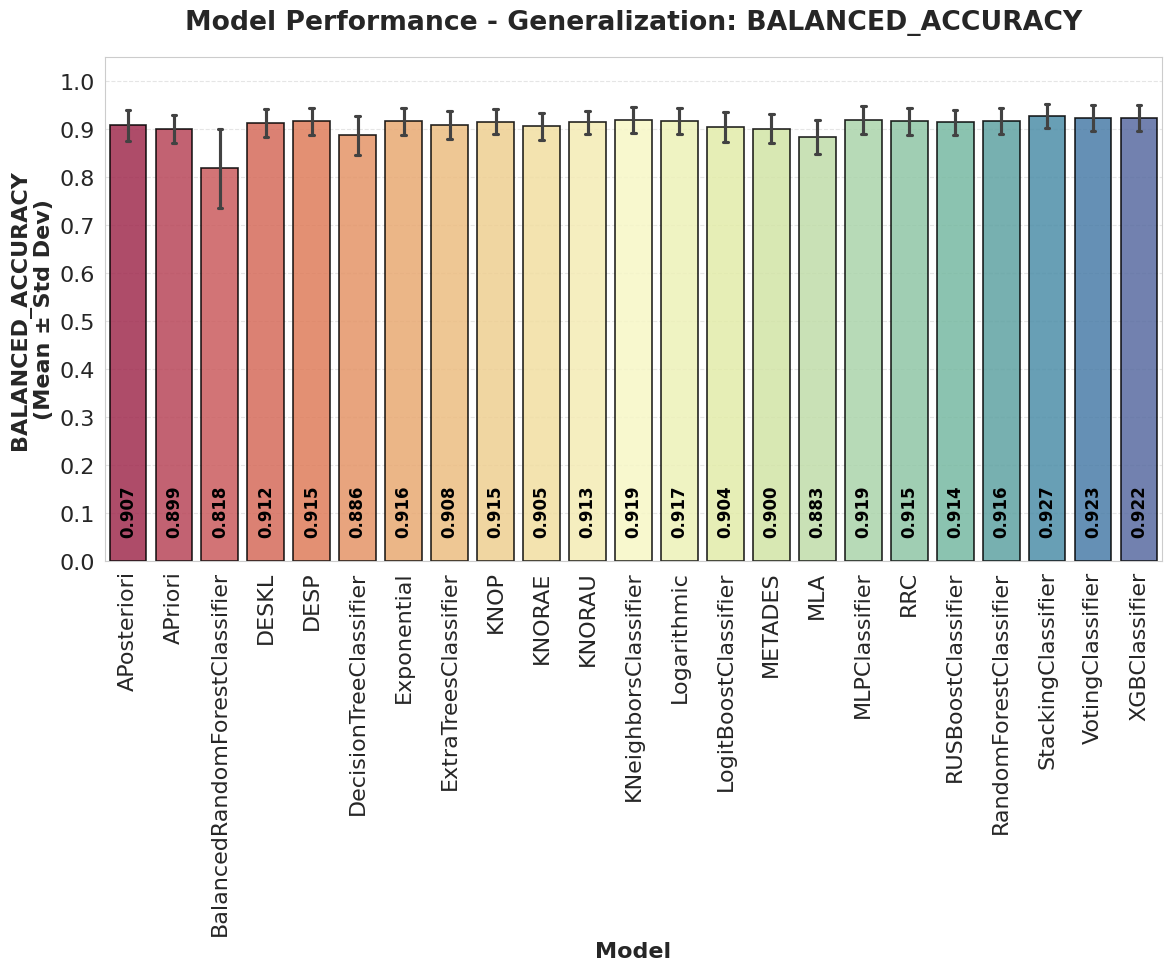


BARPLOT ANALYSIS: AVERAGE_PRECISION (GENERALIZATION)


,average_precision
model,
APosteriori,0.809 ± 0.064
APriori,0.772 ± 0.071
BalancedRandomForestClassifier,0.863 ± 0.045
DESKL,0.862 ± 0.047
DESP,0.831 ± 0.065
DecisionTreeClassifier,0.670 ± 0.126
Exponential,0.819 ± 0.074
ExtraTreesClassifier,0.869 ± 0.042
KNOP,0.843 ± 0.051


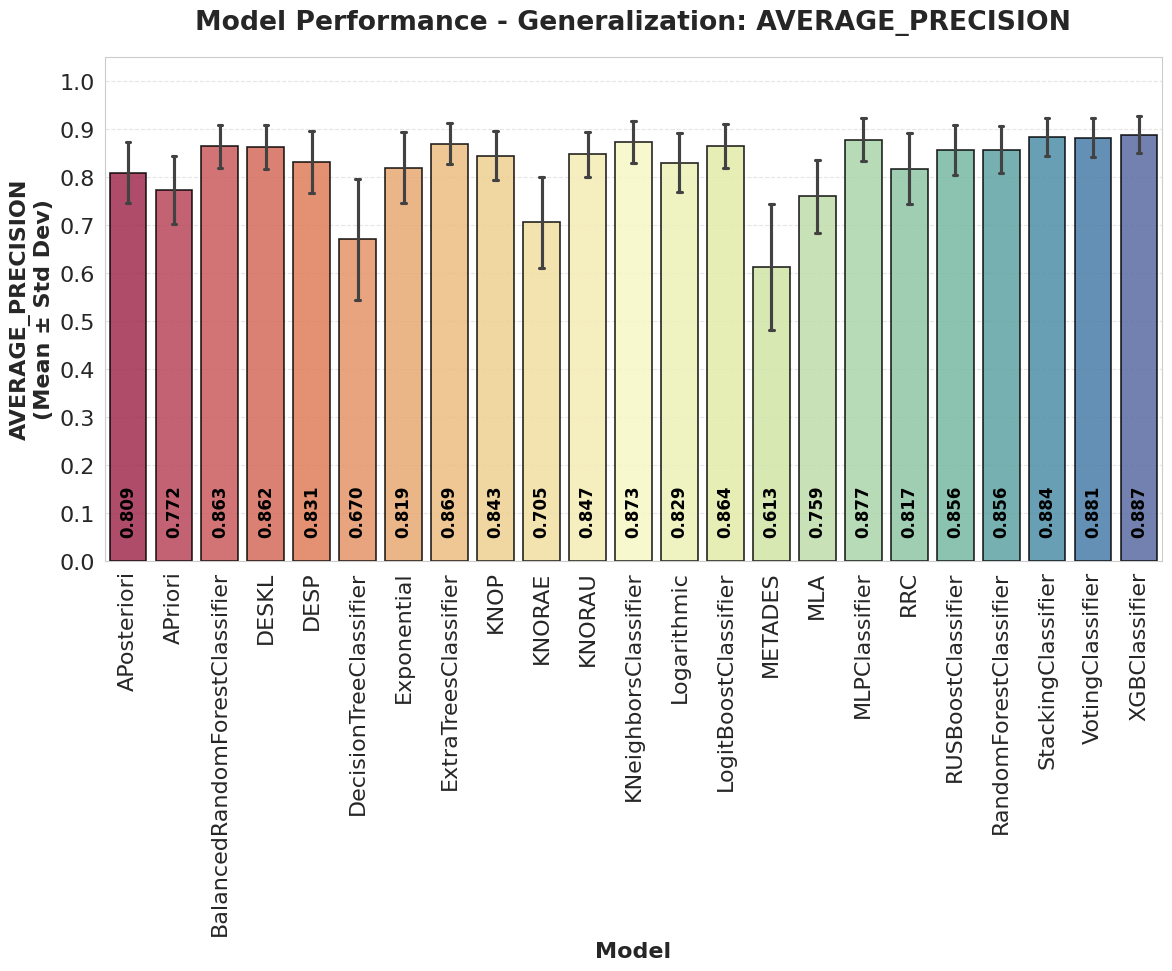


BARPLOT ANALYSIS: F1 (GENERALIZATION)


,f1
model,
APosteriori,0.817 ± 0.060
APriori,0.501 ± 0.063
BalancedRandomForestClassifier,0.128 ± 0.068
DESKL,0.877 ± 0.037
DESP,0.745 ± 0.110
DecisionTreeClassifier,0.768 ± 0.088
Exponential,0.819 ± 0.048
ExtraTreesClassifier,0.882 ± 0.036
KNOP,0.706 ± 0.155


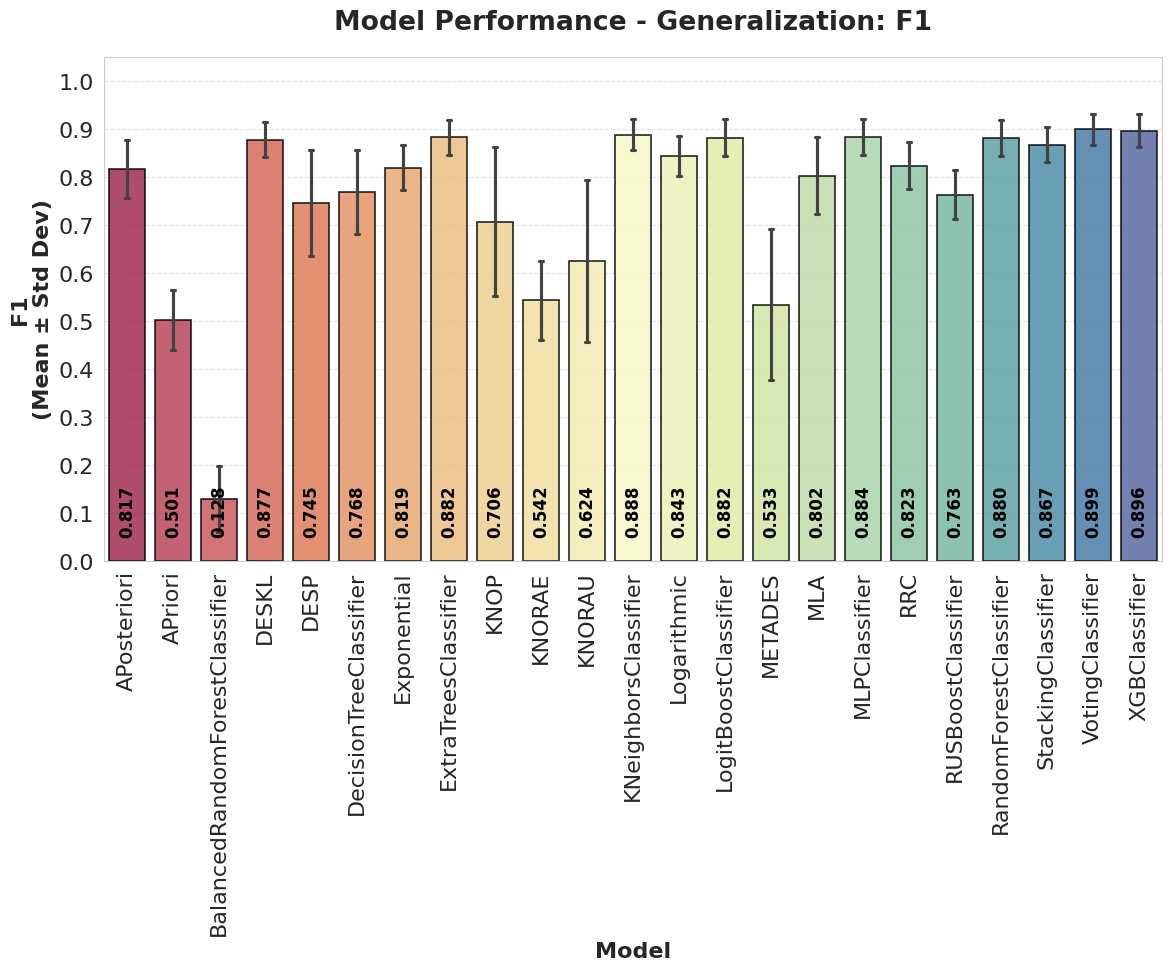


FINAL PERFORMANCE SUMMARY (Mean ± Std)


,balanced_accuracy,average_precision,f1
model,,,
APosteriori,0.907 ± 0.032,0.809 ± 0.064,0.817 ± 0.060
APriori,0.899 ± 0.029,0.772 ± 0.071,0.501 ± 0.063
BalancedRandomForestClassifier,0.818 ± 0.082,0.863 ± 0.045,0.128 ± 0.068
DESKL,0.912 ± 0.029,0.862 ± 0.047,0.877 ± 0.037
DESP,0.915 ± 0.028,0.831 ± 0.065,0.745 ± 0.110
DecisionTreeClassifier,0.886 ± 0.041,0.670 ± 0.126,0.768 ± 0.088
Exponential,0.916 ± 0.028,0.819 ± 0.074,0.819 ± 0.048
ExtraTreesClassifier,0.908 ± 0.030,0.869 ± 0.042,0.882 ± 0.036
KNOP,0.915 ± 0.026,0.843 ± 0.051,0.706 ± 0.155


In [11]:
# List to store individual metric reports
metric_reports = []

for metric in metrics_to_analyze:
    report = plot_model_barplot(df=generalization_df,
                                metric_name=metric,
                                save_path=FIGURES_MULTIPLE_MODELS_EVALUATION_DIR,
                                split_name="generalization")

    if report is not None:
        metric_reports.append(report)

# --- Final Aggregation ---
if metric_reports:
    # Concatenate all reports along columns (axis=1)
    # Since all reports share the same Index (Model Name), they will align automatically
    final_summary_df: pd.DataFrame = pd.concat(metric_reports, axis=1)

    print(f"\n{'='*80}\nFINAL PERFORMANCE SUMMARY (Mean ± Std)\n{'='*80}")
    ipd.display(final_summary_df)

    final_csv_path = FIGURES_MULTIPLE_MODELS_EVALUATION_DIR / "distribution_barplot_summary.csv"
    final_summary_df.to_csv(final_csv_path)
else:
    print("No reports were generated.")

## Model Comparison & Statistical Significance Testing

### Objective
To definitively determine which models perform better than others by moving beyond simple average scores. We aim to identify **statistically significant differences** between model pairs, ensuring that observed performance gains are real and not merely artifacts of random data splitting.

### Methodology: Corrected Resampled t-test
Standard statistical tests (like the independent t-test) assume that data samples are independent. However, in Cross-Validation, training sets overlap significantly (e.g., 90% overlap in 10-fold CV), violating this assumption and leading to underestimated variance and high False Positive rates (Type I errors).

To address this, we employ the **Corrected Resampled t-test** proposed by Nadeau and Bengio (2003). This test adjusts the variance to account for the correlation between training sets and the ratio of testing to training samples.

The corrected t-statistic is calculated as:

$$t = \frac{\mu_{diff}}{\sqrt{\sigma_{diff}^2 \cdot (\frac{1}{n} + \frac{n_{test}}{n_{train}})}}$$

Where:
* $\mu_{diff}$: Mean difference in scores between Model A and Model B.
* $\sigma_{diff}^2$: Variance of the differences.
* $n$: Number of evaluations (Iterations $\times$ Folds).
* $\frac{n_{test}}{n_{train}}$: Correction factor for the overlap between training sets.

### Visualization: Pairwise Significance Heatmap
We visualize the results using a **Significance Heatmap** for each metric. This matrix displays the outcome of the hypothesis test for every pair of models based on the p-value.

* **Rows & Columns:** Each cell represents the comparison between the model on the row and the model on the column.
* **Color Coding:**
    * **Blue Cells ($p < 0.05$):** Indicate a **statistically significant difference**. Darker blues represent higher confidence (lower p-values, e.g., $p < 0.001$).
        * *Note:* This color confirms the models are *different*, but you must check the mean scores (or the CSV `Mean_Diff`) to see which one is *better*.
    * **Orange/Red Cells (NS):** Indicate **No Significant Difference**. The models perform statistically similarly, meaning any difference in their average scores is likely due to chance.

### Interpretation Guide
1.  **Identify "Cliques":** Look for blocks of **Orange (NS)** cells. These represent groups of models that are statistically indistinguishable from each other.
2.  **Verify Improvements:** If a high-scoring model has a **Blue** cell when compared to a baseline model, the improvement is real and statistically significant.
3.  **Symmetry:** The chart is symmetric. A Blue cell at (Row A, Col B) means A and B are significantly different. Use the `df_comparisons` table to confirm if A > B or B > A.


CORRECTED RESAMPLED t-TEST ANALYSIS (Pairwise): BALANCED_ACCURACY
Comparing 'APosteriori' (mean=0.907) vs 'APriori' (mean=0.899)
  p-value: 0.5859 (t=0.5466) -> NOT significant
--------------------------------------------------------------------------------
Comparing 'APosteriori' (mean=0.907) vs 'BalancedRandomForestClassifier' (mean=0.818)
  p-value: 0.0041 (t=2.9371) -> Statistically SIGNIFICANT
--------------------------------------------------------------------------------
Comparing 'APosteriori' (mean=0.907) vs 'DESKL' (mean=0.912)
  p-value: 0.7010 (t=-0.3851) -> NOT significant
--------------------------------------------------------------------------------
Comparing 'APosteriori' (mean=0.907) vs 'DESP' (mean=0.915)
  p-value: 0.5603 (t=-0.5843) -> NOT significant
--------------------------------------------------------------------------------
Comparing 'APosteriori' (mean=0.907) vs 'DecisionTreeClassifier' (mean=0.886)
  p-value: 0.2301 (t=1.2076) -> NOT significant
---------

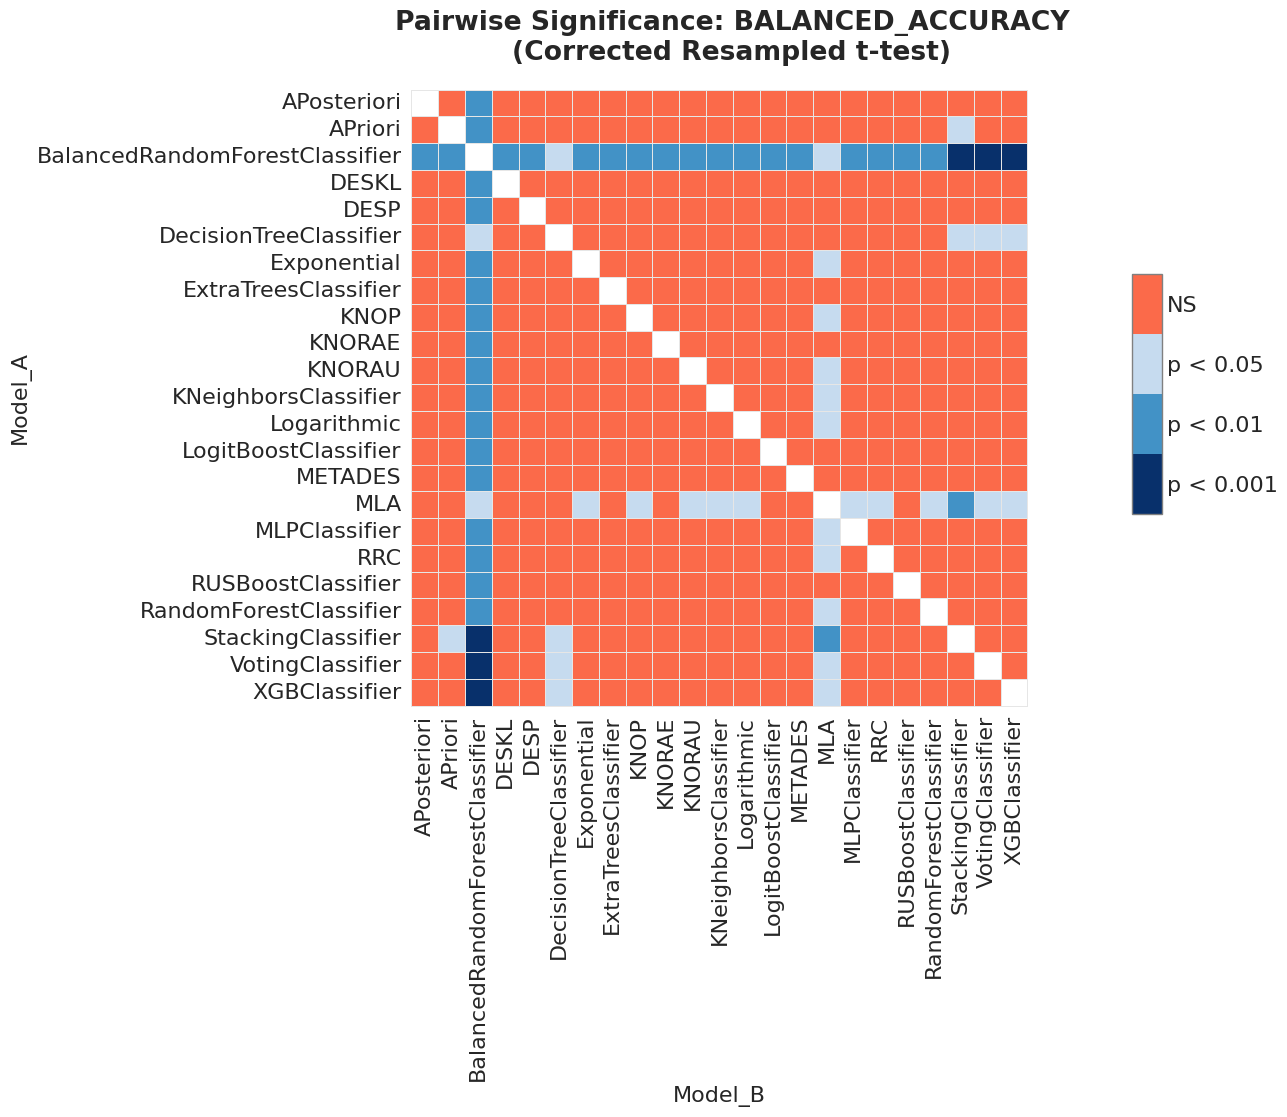

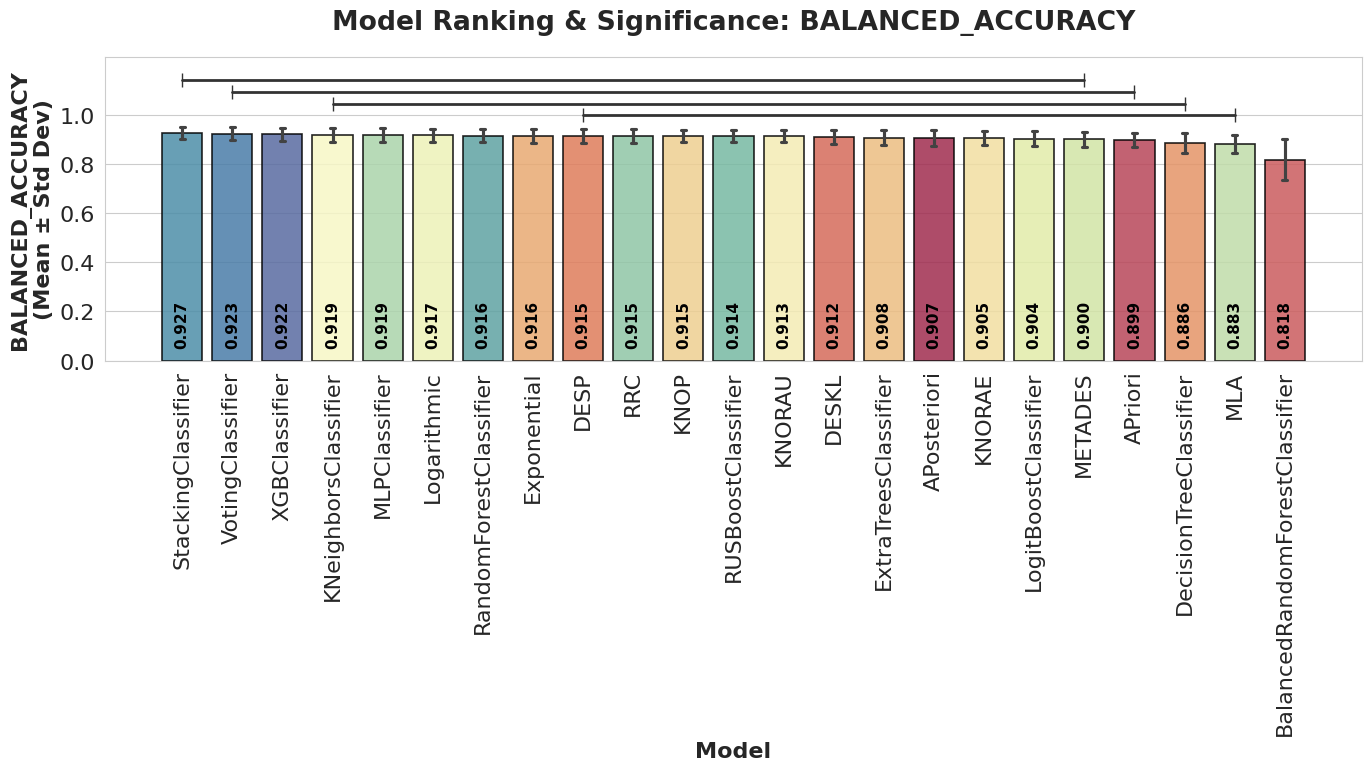


CORRECTED RESAMPLED t-TEST ANALYSIS (Pairwise): AVERAGE_PRECISION
Comparing 'APosteriori' (mean=0.809) vs 'APriori' (mean=0.772)
  p-value: 0.3050 (t=1.0311) -> NOT significant
--------------------------------------------------------------------------------
Comparing 'APosteriori' (mean=0.809) vs 'BalancedRandomForestClassifier' (mean=0.863)
  p-value: 0.0395 (t=-2.0867) -> Statistically SIGNIFICANT
--------------------------------------------------------------------------------
Comparing 'APosteriori' (mean=0.809) vs 'DESKL' (mean=0.862)
  p-value: 0.0541 (t=-1.9492) -> NOT significant
--------------------------------------------------------------------------------
Comparing 'APosteriori' (mean=0.809) vs 'DESP' (mean=0.831)
  p-value: 0.4744 (t=-0.7180) -> NOT significant
--------------------------------------------------------------------------------
Comparing 'APosteriori' (mean=0.809) vs 'DecisionTreeClassifier' (mean=0.670)
  p-value: 0.0041 (t=2.9421) -> Statistically SIGNIFICAN

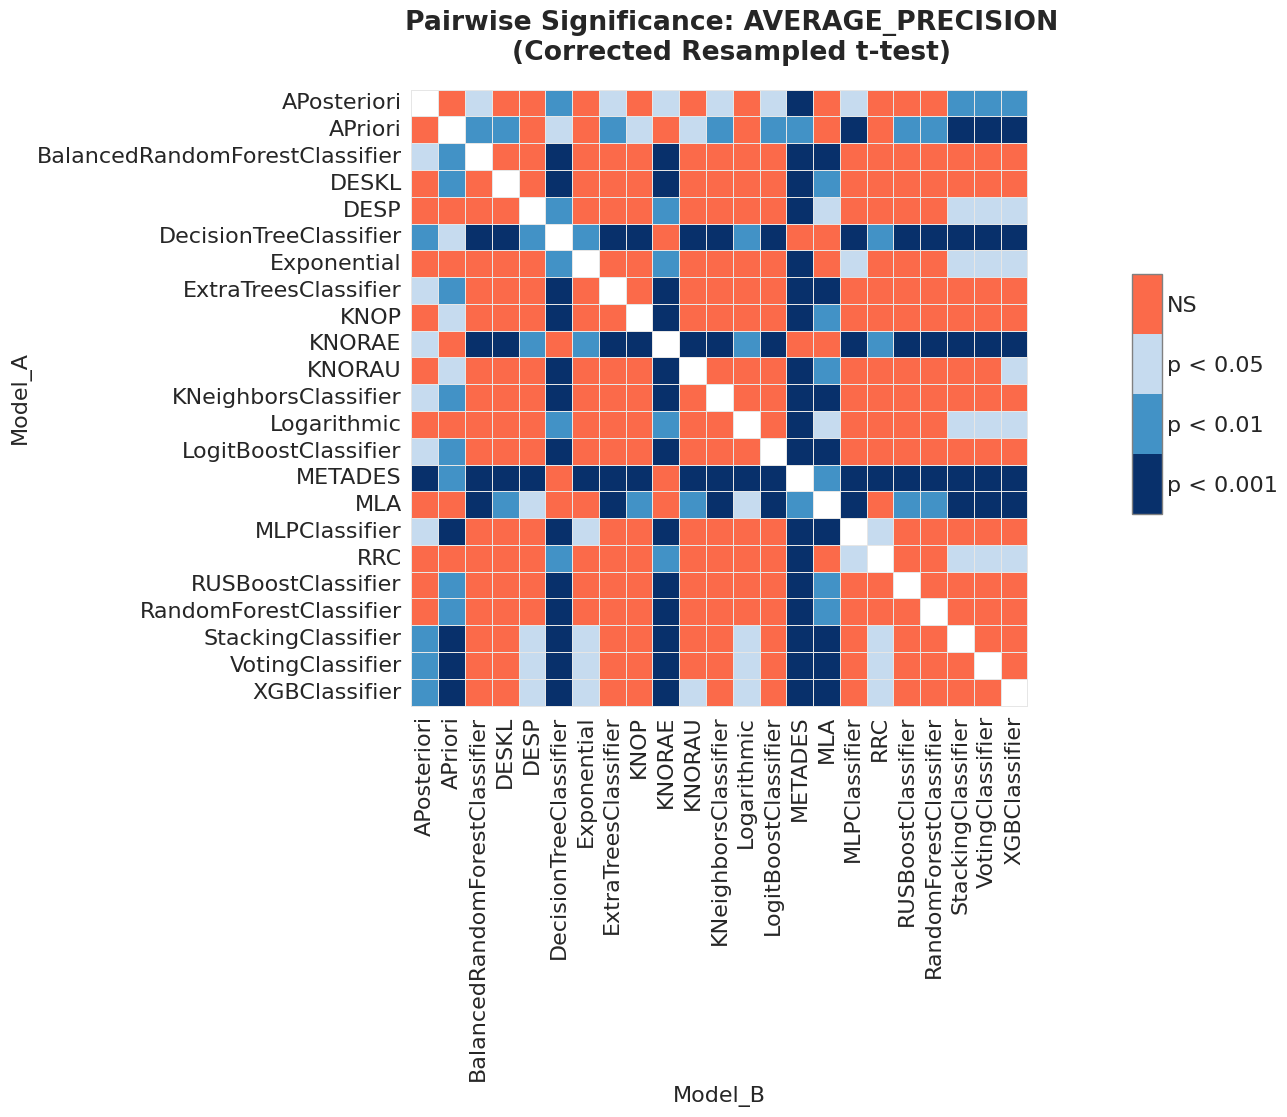

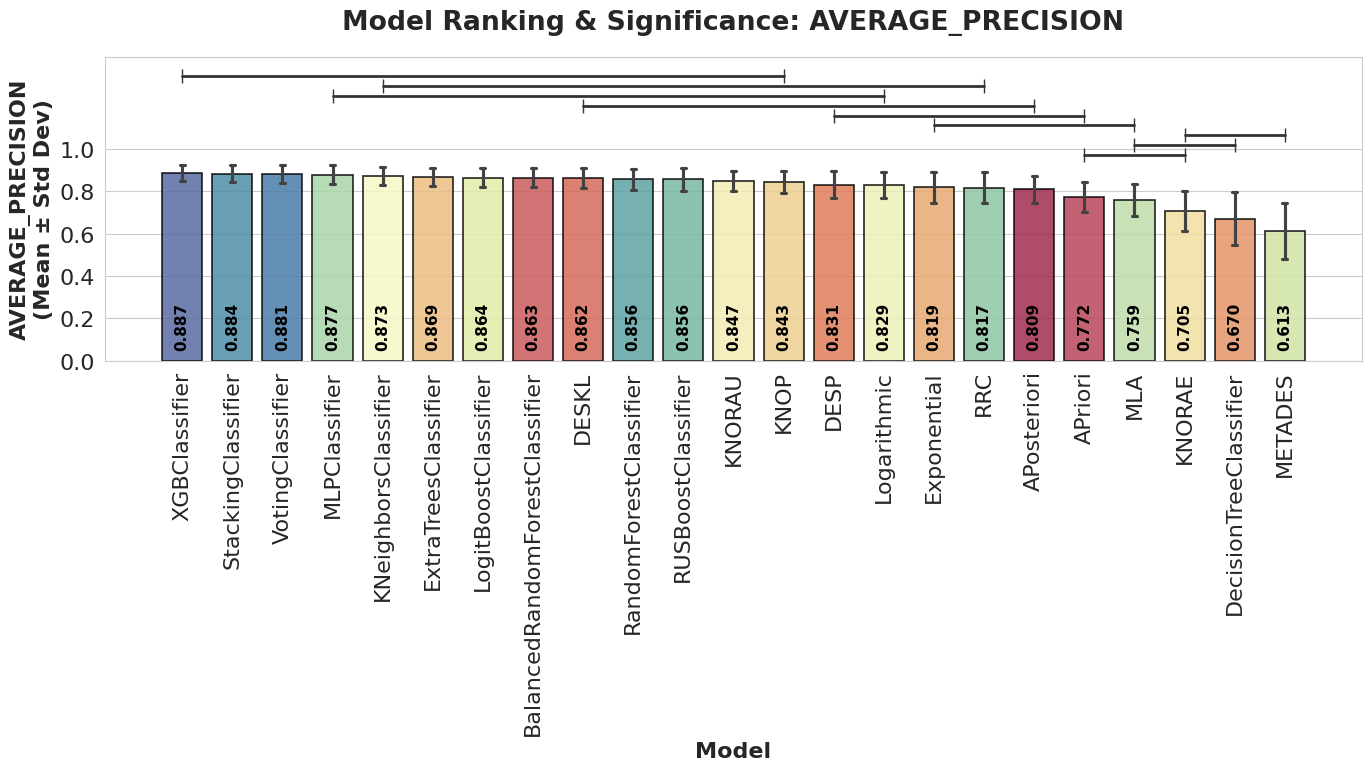


CORRECTED RESAMPLED t-TEST ANALYSIS (Pairwise): F1
Comparing 'APosteriori' (mean=0.817) vs 'APriori' (mean=0.501)
  p-value: 0.0000 (t=10.6913) -> Statistically SIGNIFICANT
--------------------------------------------------------------------------------
Comparing 'APosteriori' (mean=0.817) vs 'BalancedRandomForestClassifier' (mean=0.128)
  p-value: 0.0000 (t=20.1423) -> Statistically SIGNIFICANT
--------------------------------------------------------------------------------
Comparing 'APosteriori' (mean=0.817) vs 'DESKL' (mean=0.877)
  p-value: 0.0118 (t=-2.5668) -> Statistically SIGNIFICANT
--------------------------------------------------------------------------------
Comparing 'APosteriori' (mean=0.817) vs 'DESP' (mean=0.745)
  p-value: 0.1164 (t=1.5839) -> NOT significant
--------------------------------------------------------------------------------
Comparing 'APosteriori' (mean=0.817) vs 'DecisionTreeClassifier' (mean=0.768)
  p-value: 0.2083 (t=1.2664) -> NOT significant
---

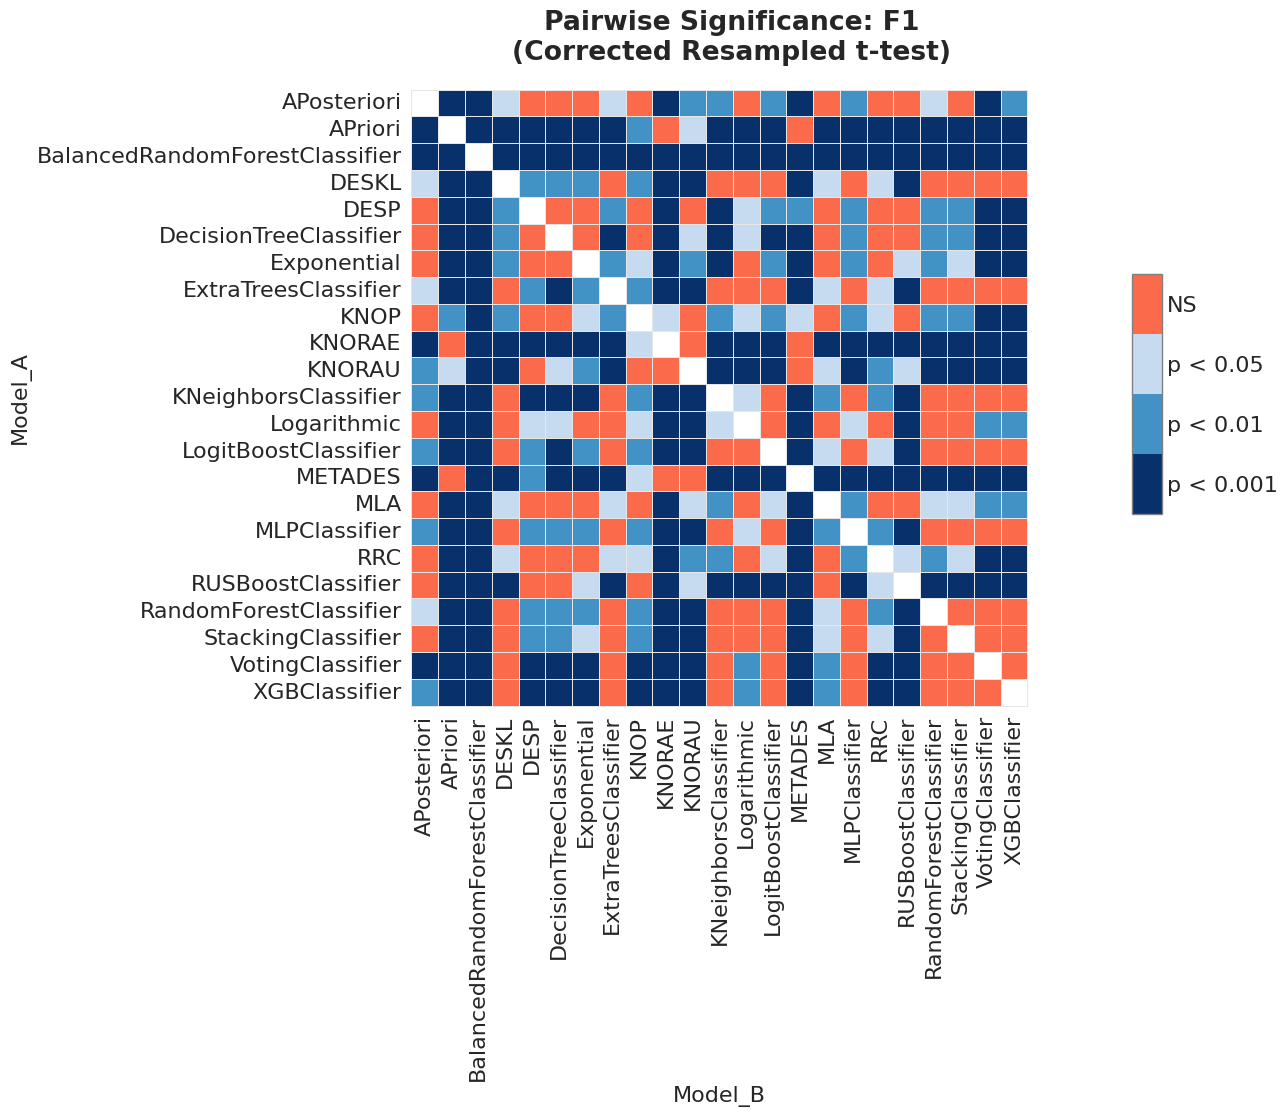

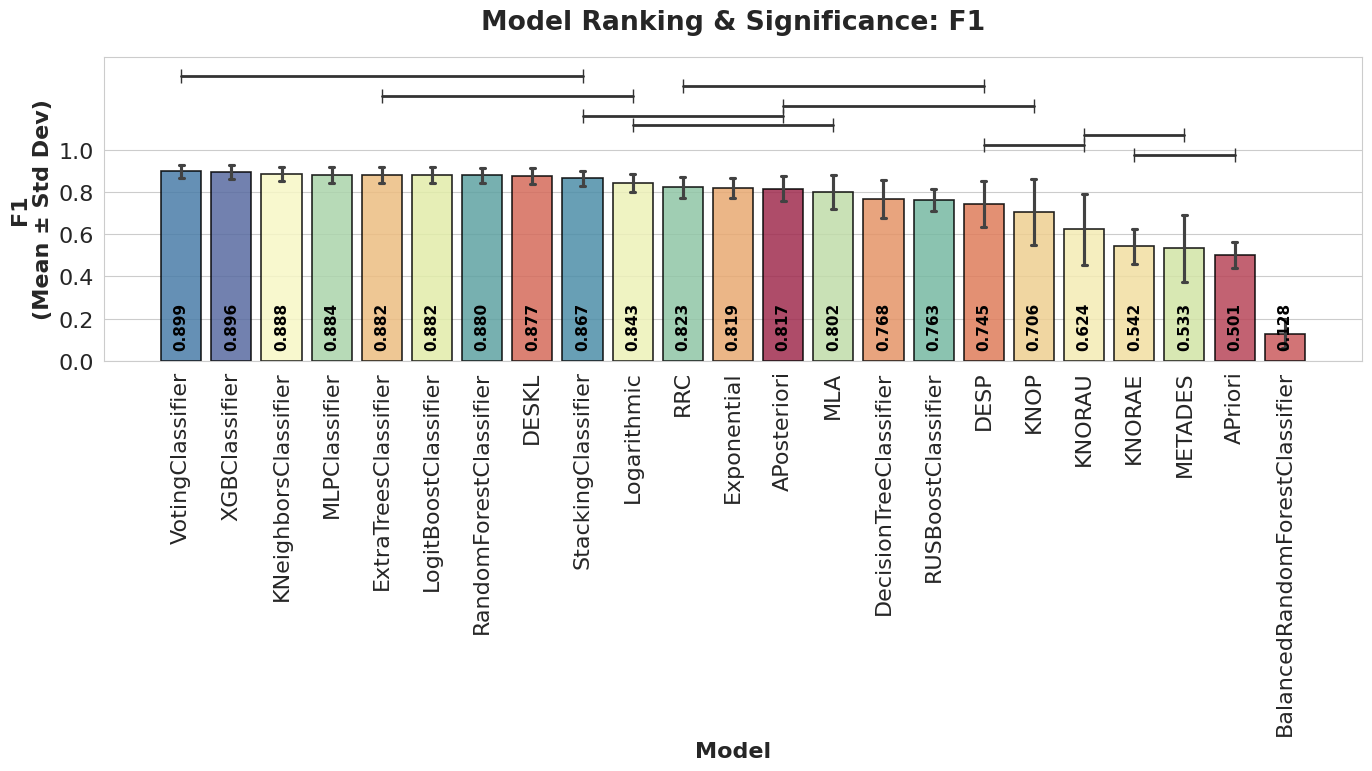


FINAL CORRECTED RESAMPLED t-TEST SUMMARY


,Metric,Model_A,Model_B,Mean_Diff,t-stat,p-value,is_significant,result
0,balanced_accuracy,APosteriori,APriori,0.008032,0.546603,5.858811e-01,False,No Diff
1,balanced_accuracy,APosteriori,BalancedRandomForestClassifier,0.088798,2.937105,4.120675e-03,True,Better
2,balanced_accuracy,APosteriori,DESKL,-0.005416,-0.385144,7.009567e-01,False,No Diff
3,balanced_accuracy,APosteriori,DESP,-0.008606,-0.584331,5.603265e-01,False,No Diff
4,balanced_accuracy,APosteriori,DecisionTreeClassifier,0.020540,1.207588,2.300830e-01,False,No Diff
...,...,...,...,...,...,...,...,...
501,f1,XGBClassifier,RRC,0.073181,3.636367,4.410534e-04,True,Better
502,f1,XGBClassifier,RUSBoostClassifier,0.133384,6.182229,1.418611e-08,True,Better
503,f1,XGBClassifier,RandomForestClassifier,0.015771,0.844735,4.002954e-01,False,No Diff
504,f1,XGBClassifier,StackingClassifier,0.028948,1.740785,8.482822e-02,False,No Diff


In [12]:
pairwise_frames = []

for metric in metrics_to_analyze:
    report = compute_pairwise_corrected_resampled_ttest(
        df=generalization_df,
        metric_name=metric, # Pass single string here
        n_train=0.9,
        n_test=0.1,
        save_path=FIGURES_MULTIPLE_MODELS_EVALUATION_DIR
    )

    if report is not None:
        pairwise_frames.append(report)

# --- Aggregate & Save Master CSV ---
if pairwise_frames:
    # Concatenate all metric-specific dataframes vertically (stacking rows)
    final_comparisons_df: pd.DataFrame = pd.concat(pairwise_frames, axis=0)

    print(f"\n{'='*80}\nFINAL CORRECTED RESAMPLED t-TEST SUMMARY\n{'='*80}")
    ipd.display(final_comparisons_df)

    # Define filename
    final_csv_path = FIGURES_MULTIPLE_MODELS_EVALUATION_DIR / "corrected_resampled_ttest_summary.csv"
    final_comparisons_df.to_csv(final_csv_path, index=False)
else:
    print("No pairwise comparisons were generated.")